# 学習（learning）

このNotebookでやること：

1. 前処理済みデータの読み込み
2. バリデーション戦略の確認（GroupKFold）
3. alphaのチューニング
4. 最終モデルの学習・保存

**入力ファイル（`models/` フォルダ）**

| ファイル | 内容 |
|---|---|
| `models/X_train.npy` | 前処理済みtrain特徴量 |
| `models/y_train.npy` | log変換済みtrain目的変数 |

**出力ファイル（`models/` フォルダ）**

| ファイル | 内容 |
|---|---|
| `models/model.pkl` | 学習済みRidgeモデル |

## 1. ライブラリの読み込み

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import joblib
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# Noto Sans CJK JP を指定（環境に既存のフォント）
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['figure.dpi'] = 120

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


## 2. データの読み込み

In [11]:
# 前処理済み特徴量・目的変数
X_train = np.load('models/X_train.npy')
y_train = np.load('models/y_train.npy')  # log変換済み

# GroupKFold用に樹種番号を読み込む
train_raw = pd.read_csv('../data/train.csv', encoding='shift-jis')
train_raw.columns = (
    ['sample_number', 'species_number', 'species_name', 'moisture_content']
    + list(train_raw.columns[4:])
)
groups = train_raw['species_number'].values  # グループ分割のキー

print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'樹種の種類数: {len(np.unique(groups))}')

X_train: (1322, 20)
y_train: (1322,)
樹種の種類数: 13


## 3. バリデーション戦略：GroupKFold

**なぜ通常のKFoldではなくGroupKFoldを使うのか**

通常のKFold（ランダム分割）では、同じ樹種のサンプルがtrainとvalidationの両方に入ります。
するとモデルは「同じ樹種を学習して同じ樹種を予測する」という楽な問題を解くことになり、
スコアが実態より良く見えてしまいます（楽観的バイアス）。

本番のtestデータはtrainにない樹種だけが含まれるため、
「ある樹種が**丸ごと**validationに回る」分割でモデルを評価する必要があります。
これがGroupKFoldです。

```
通常KFold   : [種1,種3,種12] → train  /  [種1,種3,種12の一部] → val  ← NG
GroupKFold  : [種3,種4,種5,種8,種11,種12,種13,種14,種15,種16] → train  /  [種1,種17,種19] → val  ← OK
```

In [12]:
# GroupKFoldの分割内容を確認
gkf = GroupKFold(n_splits=5)

print('GroupKFold の分割確認（各foldのvalidation樹種）')
print('-' * 45)
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    val_species = sorted(np.unique(groups[val_idx]))
    n_val = len(val_idx)
    print(f'Fold {fold+1}: validation樹種={val_species}  ({n_val}サンプル)')

GroupKFold の分割確認（各foldのvalidation樹種）
---------------------------------------------
Fold 1: validation樹種=[np.int64(11), np.int64(12)]  (271サンプル)
Fold 2: validation樹種=[np.int64(5), np.int64(14)]  (232サンプル)
Fold 3: validation樹種=[np.int64(15), np.int64(17), np.int64(19)]  (256サンプル)
Fold 4: validation樹種=[np.int64(1), np.int64(3), np.int64(4)]  (291サンプル)
Fold 5: validation樹種=[np.int64(8), np.int64(13), np.int64(16)]  (272サンプル)


## 4. alphaのチューニング

Ridge回帰の `alpha` は「過学習をどれだけ抑えるか」を決めるハイパーパラメータです。

- alpha が小さすぎる → 過学習しやすい（trainに過剰適合、testで精度が落ちる）
- alpha が大きすぎる → 過学習は防げるが、表現力が落ちて精度が上がらない

GroupKFoldで複数のalphaを試して、最も良いものを選びます。

In [13]:
alphas = [500, 800, 1000, 1200, 1500, 1800, 2000, 2500]
results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    rmse_log_folds  = []
    rmse_orig_folds = []

    for tr_idx, val_idx in gkf.split(X_train, y_train, groups):
        model.fit(X_train[tr_idx], y_train[tr_idx])

        y_pred_log  = model.predict(X_train[val_idx])
        y_pred_orig = np.expm1(y_pred_log)
        y_val_orig  = np.expm1(y_train[val_idx])

        rmse_log_folds.append(
            np.sqrt(mean_squared_error(y_train[val_idx], y_pred_log))
        )
        rmse_orig_folds.append(
            np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
        )

    results.append({
        'alpha'          : alpha,
        'rmse_log_mean'  : np.mean(rmse_log_folds),
        'rmse_log_std'   : np.std(rmse_log_folds),
        'rmse_orig_mean' : np.mean(rmse_orig_folds),
        'rmse_orig_std'  : np.std(rmse_orig_folds),
    })

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))
print()

best_row = results_df.loc[results_df['rmse_orig_mean'].idxmin()]
BEST_ALPHA = int(best_row['alpha'])
print(f'最良のalpha: {BEST_ALPHA}  (CV RMSE={best_row["rmse_orig_mean"]:.4f})')

 alpha  rmse_log_mean  rmse_log_std  rmse_orig_mean  rmse_orig_std
   500         0.5698        0.1357         31.2250        14.6302
   800         0.5379        0.1208         28.7080        14.2516
  1000         0.5268        0.1253         27.6199        14.5262
  1200         0.5199        0.1322         26.8193        14.8309
  1500         0.5145        0.1420         26.0053        15.2053
  1800         0.5129        0.1496         25.5295        15.4606
  2000         0.5133        0.1534         25.3518        15.5766
  2500         0.5174        0.1597         25.2532        15.7369

最良のalpha: 2500  (CV RMSE=25.2532)


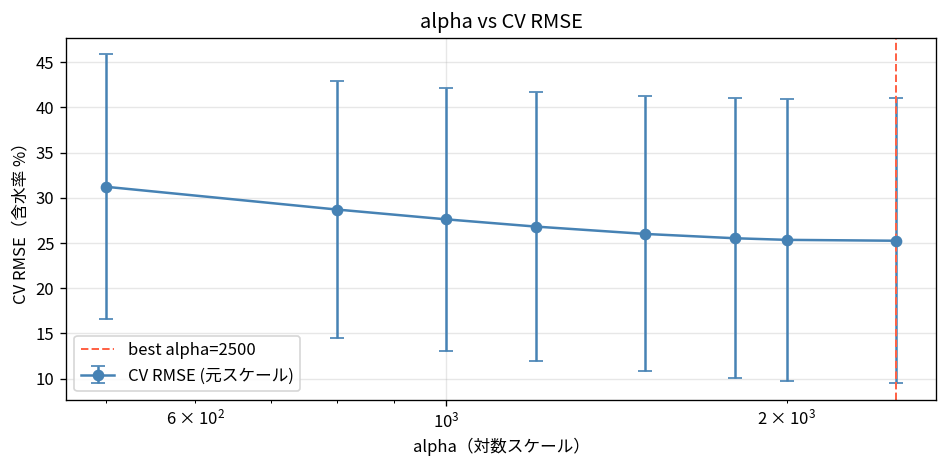

In [14]:
# alphaとRMSEの関係をグラフで確認
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    results_df['alpha'],
    results_df['rmse_orig_mean'],
    yerr=results_df['rmse_orig_std'],
    marker='o', linewidth=1.5, capsize=4, color='steelblue', label='CV RMSE (元スケール)'
)
ax.axvline(BEST_ALPHA, color='tomato', linestyle='--', linewidth=1.2,
           label=f'best alpha={BEST_ALPHA}')
ax.set_xscale('log')
ax.set_xlabel('alpha（対数スケール）')
ax.set_ylabel('CV RMSE（含水率 %）')
ax.set_title('alpha vs CV RMSE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 最終モデルの学習

最良の alpha を使って、train全データで再学習します。

**なぜ全データで再学習するのか**
バリデーション時は「評価のためにデータの一部をわざとモデルに見せない」という操作をしていました。
最終モデルは提出用なので、より多くのデータで学習した方が精度が上がります。

In [15]:
final_model = Ridge(alpha=BEST_ALPHA)
final_model.fit(X_train, y_train)

# train全体での参考RMSE（過学習の確認用。本番スコアとは異なる）
y_pred_train_log  = final_model.predict(X_train)
y_pred_train_orig = np.expm1(y_pred_train_log)
y_train_orig      = np.expm1(y_train)

train_rmse = np.sqrt(mean_squared_error(y_train_orig, y_pred_train_orig))
print(f'最終モデル（alpha={BEST_ALPHA}）')
print(f'train RMSE（参考値）: {train_rmse:.4f}  ← CV RMSEより低いのは正常')

最終モデル（alpha=2500）
train RMSE（参考値）: 27.2958  ← CV RMSEより低いのは正常


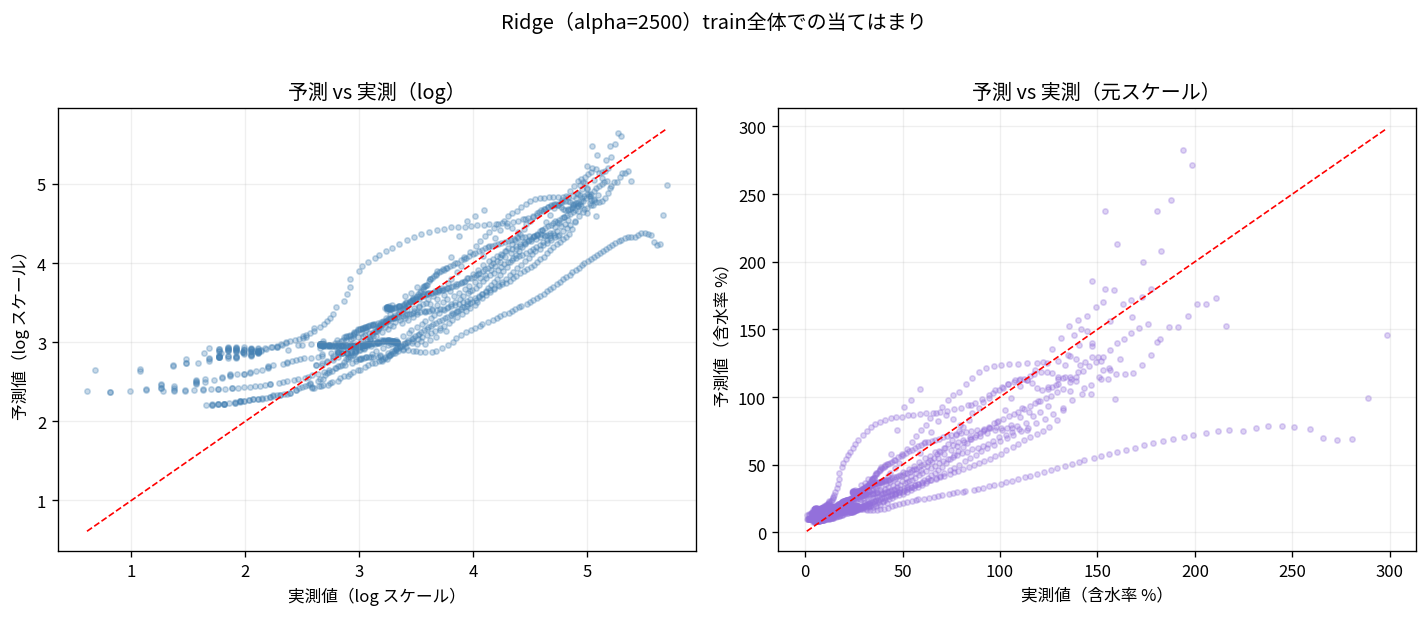

In [16]:
# 予測値 vs 実測値のグラフ（モデルの当てはまりを確認）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# log スケール
axes[0].scatter(y_train, y_pred_train_log, alpha=0.3, s=10, color='steelblue')
lim = [y_train.min(), y_train.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1)
axes[0].set_xlabel('実測値（log スケール）')
axes[0].set_ylabel('予測値（log スケール）')
axes[0].set_title('予測 vs 実測（log）')
axes[0].grid(alpha=0.2)

# 元スケール
axes[1].scatter(y_train_orig, y_pred_train_orig, alpha=0.3, s=10, color='mediumpurple')
lim2 = [y_train_orig.min(), y_train_orig.max()]
axes[1].plot(lim2, lim2, 'r--', linewidth=1)
axes[1].set_xlabel('実測値（含水率 %）')
axes[1].set_ylabel('予測値（含水率 %）')
axes[1].set_title('予測 vs 実測（元スケール）')
axes[1].grid(alpha=0.2)

plt.suptitle(f'Ridge（alpha={BEST_ALPHA}）train全体での当てはまり', y=1.02)
plt.tight_layout()
plt.show()

## 6. モデルの保存

In [17]:
joblib.dump(final_model, 'models/model.pkl')

print('モデル保存完了: models/model.pkl')
print()
print(f'  アルゴリズム : Ridge回帰')
print(f'  alpha        : {BEST_ALPHA}')
print(f'  CV RMSE      : {best_row["rmse_orig_mean"]:.4f} ± {best_row["rmse_orig_std"]:.4f}')
print()
print('次は predicting.ipynb に進んでください。')

モデル保存完了: models/model.pkl

  アルゴリズム : Ridge回帰
  alpha        : 2500
  CV RMSE      : 25.2532 ± 15.7369

次は predicting.ipynb に進んでください。
